# session 2 - web scraping
# objectif : récupérer des données depuis un site web automatiquement

In [1]:
!pip install requests beautifulsoup4

zsh:1: command not found: pip


In [2]:
import requests # pour récupérer le contenu d'une page web
from bs4 import BeautifulSoup # pour analyser le HTML pour récupérer les infos qui m'intéressent

In [3]:
# je mets des headers plus complets pour simuler un vrai navigateur
url = "https://www.imdb.com/chart/top/"

headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)",
    "Accept-Language": "en-US,en;q=0.9"
}

response = requests.get(url, headers=headers)

print(response.status_code)

200


In [4]:
# je vérifie que la page a bien été récupérée

print(response.text[:500])

<!DOCTYPE html><html lang="en-US" xmlns:og="http://opengraphprotocol.org/schema/" xmlns:fb="http://www.facebook.com/2008/fbml"><head><meta charSet="utf-8"/><meta name="viewport" content="width=device-width"/><script>if(typeof uet === 'function'){ uet('bb', 'LoadTitle', {wb: 1}); }</script><script>window.addEventListener('load', (event) => {
        if (typeof window.csa !== 'undefined' && typeof window.csa === 'function') {
            var csaLatencyPlugin = window.csa('Content', {
             


In [5]:
# je transforme le HTML en objet exploitable avec BeautifulSoup
soup = BeautifulSoup(response.text, 'html.parser')

In [6]:
print(soup.title)

<title>IMDb Top 250 movies</title>


In [7]:
# je cherche tous les blocs contenant les films
movies = soup.find_all('li')

In [8]:
print(len(movies))

78


In [9]:
# je récupère tous les blocs de films avec la bonne classe
movies = soup.select('li.ipc-metadata-list-summary-item')

In [10]:
print(len(movies))

25


In [11]:
# j'affiche le premier bloc film pour voir sa structure HTML
print(movies[0].prettify())

<li class="ipc-metadata-list-summary-item">
 <div class="ipc-metadata-list-summary-item__c">
  <div class="ipc-metadata-list-summary-item__tc">
   <span aria-disabled="false" class="ipc-metadata-list-summary-item__t ipc-btn--not-interactable">
   </span>
   <div class="sc-fc35a1ef-1 lmHCrT cli-parent li-compact">
    <div class="sc-fc35a1ef-0 hTMtRz">
     <div class="sc-62a56b6a-0 eUlMPU cli-poster-container">
      <div class="ipc-poster ipc-poster--base ipc-poster--media-radius ipc-poster--wl-true ipc-poster--dynamic-width ipc-sub-grid-item ipc-sub-grid-item--span-2" role="group">
       <div class="ipc-media ipc-media--poster-27x40 ipc-image-media-ratio--poster-27x40 ipc-media--media-radius ipc-media--base ipc-media--poster-s ipc-poster__poster-image ipc-media__img" style="width:100%">
        <img alt="Tim Robbins in The Shawshank Redemption (1994)" class="ipc-image" loading="lazy" sizes="50vw, (min-width: 480px) 34vw, (min-width: 600px) 26vw, (min-width: 1024px) 16vw, (min-width:

In [12]:
first_movie = movies[0]

# le titre dans la balise h3
title = first_movie.find('h3').get_text(strip=True)

print(title)

The Shawshank Redemption


In [13]:
# je récupère l'année du film (elle est dans un span)
year = first_movie.find('span', class_='cli-title-metadata-item').get_text(strip=True)

print(year)

1994


In [14]:
# je récupère la note imdb du film
rating = first_movie.find('span', class_='ipc-rating-star--rating').get_text(strip=True)

print(rating)

9.3


In [15]:
# maintenant que j'ai testé sur un film, je fais une boucle sur toute la liste
# le but est de récupérer les infos principales de chaque film dans une liste

movies_data = []

for movie in movies:
    title = movie.find('h3').get_text(strip=True)
    year = movie.find('span', class_='cli-title-metadata-item').get_text(strip=True)
    rating = movie.find('span', class_='ipc-rating-star--rating').get_text(strip=True)

    movies_data.append({
        'title': title,
        'year': year,
        'rating': rating
    })

print(movies_data[:3])

[{'title': 'The Shawshank Redemption', 'year': '1994', 'rating': '9.3'}, {'title': 'The Godfather', 'year': '1972', 'rating': '9.2'}, {'title': 'The Dark Knight', 'year': '2008', 'rating': '9.1'}]


In [16]:
# j'importe pandas pour créer un tableau propre
import pandas as pd

# je transforme ma liste en dataframe
df = pd.DataFrame(movies_data)

# j'affiche les premières lignes
df.head()

,title,year,rating
0,The Shawshank Redemption,1994,9.3
1,The Godfather,1972,9.2
2,The Dark Knight,2008,9.1
3,The Godfather Part II,1974,9.0
4,12 Angry Men,1957,9.0


In [17]:
# j'enregistre les données dans un fichier csv
df.to_csv("imdb_movies.csv", index=False)

In [18]:
# les films les mieux notés
df.sort_values(by='rating', ascending=False).head()

,title,year,rating
0,The Shawshank Redemption,1994,9.3
1,The Godfather,1972,9.2
2,The Dark Knight,2008,9.1
3,The Godfather Part II,1974,9.0
4,12 Angry Men,1957,9.0


In [19]:
# les films les plus anciens
df.sort_values(by='year').head()

,title,year,rating
20,It's a Wonderful Life,1946,8.6
22,Seven Samurai,1954,8.6
4,12 Angry Men,1957,9.0
9,"The Good, the Bad and the Ugly",1966,8.8
1,The Godfather,1972,9.2


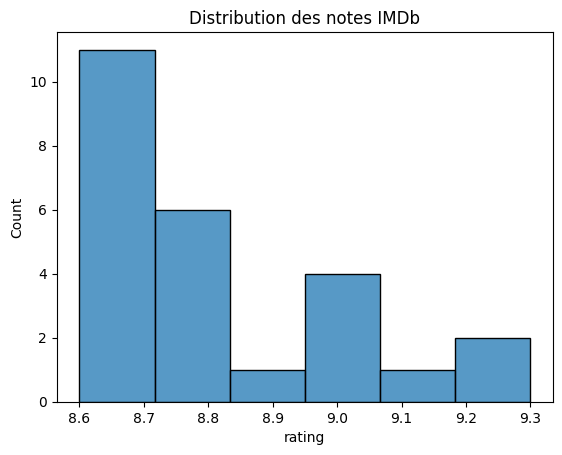

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# je convertis rating en float pour pouvoir l'utiliser
df['rating'] = df['rating'].astype(float)

# histogramme des notes
sns.histplot(df['rating'])
plt.title("Distribution des notes IMDb")
plt.show()